# Proyecto: Predicción inteligente de gasto en clientes e-commerce


**Descripción del objetivo del negocio**            

La empresa de e-commerce busca optimizar su estrategia de marketing mediante la personalización de ofertas para sus clientes. Para lograrlo, necesita comprender y anticipar el comportamiento de compra de los usuarios a partir de sus interacciones con la plataforma digital.               

En particular, el objetivo del negocio es predecir el gasto anual de los clientes, utilizando información relacionada con su comportamiento en la plataforma, como la duración promedio de sus sesiones, el tiempo que pasan en la aplicación móvil o en el sitio web, y la antigüedad que tienen como miembros del servicio.               

Contar con un modelo predictivo de este tipo permitiría a la empresa:               

- Identificar clientes con mayor potencial de gasto          

- Diseñar campañas de marketing más personalizadas       

- Optimizar la asignación de recursos comerciales        

- Mejorar la experiencia del cliente mediante recomendaciones más relevantes.         

En este contexto, el uso de técnicas de aprendizaje automático supervisado permite construir un modelo capaz de aprender patrones a partir de datos históricos y generar estimaciones del gasto esperado de los clientes.           

Para el desarrollo de este proyecto se seleccionó el dataset “Ecommerce Customers” disponible en Kaggle, ya que es un conjunto de datos ampliamente utilizado en ejercicios de análisis y aprendizaje automático enfocados en comportamiento de clientes. El dataset contiene información de 500 clientes de una empresa de comercio electrónico, incluyendo variables relacionadas con su interacción con la plataforma y su gasto anual. Entre sus principales variables se encuentran, la duración promedio de las sesiones, el tiempo que los usuarios pasan en la aplicación móvil y en el sitio web, la duración de la membresía y el monto anual gastado por cada cliente, que corresponde a la variable objetivo del análisis.

Este dataset fue elegido porque presenta variables numéricas claras y una variable objetivo continua, lo que lo hace adecuado para aplicar técnicas de regresión y comparar distintos modelos de machine learning. Además, su tamaño moderado y estructura simple facilitan el desarrollo de todo el flujo de trabajo del proyecto, desde el análisis exploratorio hasta la evaluación de modelos predictivos.

In [179]:
import pandas as pd
import numpy as np

df = pd.read_csv("Ecommerce Customers.csv")

df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


Reviso estructura del Dataset

In [180]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


Con el objetivo de incorporar una variable categórica útil para el modelo, se extrajo el estado de residencia del cliente a partir de la columna Address. Esta información fue utilizada para crear una nueva variable llamada State, que representa el estado de Estados Unidos donde reside el cliente. Posteriormente, las columnas Email, Address y Avatar fueron eliminadas debido a que no aportan valor predictivo al modelo.

In [181]:
df["State"] = df["Address"].str.extract(r',\s([A-Z]{2})\s')

In [182]:
df[["Address", "State"]].head()

,Address,State
0,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",MI
1,"4547 Archer Common\nDiazchester, CA 06566-8576",CA
2,"24645 Valerie Unions Suite 582\nCobbborough, D...",DC
3,"1414 David Throughway\nPort Jason, OH 22070-1220",OH
4,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",PR


In [183]:
#Verifico Estados únicos y su frecuencia
df["State"].value_counts()

State
MO    13
SC    13
DE    13
OR    12
VT    12
MS    11
FL    11
KS    11
MN    11
NC    10
NJ    10
HI     9
AL     9
WV     9
ME     9
ND     9
MI     9
AS     9
AZ     9
KY     8
GA     8
FM     8
IL     8
PA     8
NY     8
TX     8
MT     8
MA     7
IA     7
OK     7
RI     7
NH     7
AK     7
IN     7
MH     7
SD     7
DC     7
WY     7
PR     7
NM     6
CA     6
PW     6
VI     6
AR     6
VA     6
GU     6
NE     6
LA     6
NV     6
OH     5
MP     5
CT     5
CO     5
TN     5
UT     5
MD     5
WI     5
WA     4
ID     3
Name: count, dtype: int64

In [184]:
df["State"].nunique()

59

Elimino variables innecesarias para el proyecto

In [185]:
df = df.drop(["Email", "Address", "Avatar"], axis=1)

Hago una primera revisión de valores nulos

In [186]:
df.isnull().sum()

Avg. Session Length      0
Time on App              0
Time on Website          0
Length of Membership     0
Yearly Amount Spent      0
State                   46
dtype: int64

**Reviso el Dataset**

In [187]:
df.head()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent,State
0,34.497268,12.655651,39.577668,4.082621,587.951054,MI
1,31.926272,11.109461,37.268959,2.664034,392.204933,CA
2,33.000915,11.330278,37.110597,4.104543,487.547505,DC
3,34.305557,13.717514,36.721283,3.120179,581.852344,OH
4,33.330673,12.795189,37.536653,4.446308,599.406092,PR


**Tabla de variables y su descripción**

| Variable (Inglés)    | Variable (Español)            | Tipo de variable      | Unidad de medida |
| -------------------- | ----------------------------- | --------------------- | ---------------- |
| Avg. Session Length  | Duración promedio de sesión   | Cuantitativa continua | Minutos          |
| Time on App          | Tiempo en la aplicación móvil | Cuantitativa continua | Minutos          |
| Time on Website      | Tiempo en el sitio web        | Cuantitativa continua | Minutos          |
| Length of Membership | Antigüedad del cliente        | Cuantitativa continua | Años             |
| Yearly Amount Spent  | Gasto anual del cliente       | Cuantitativa continua | Dólares (USD)    |
| State                | Estado donde vive el cliente  | Categórica nominal    | -                |

Guardo el dataset editado y lo vuelvo a cargar para trabajar con este nuevo dataset

In [188]:
df.to_csv("ecommerce_ml_dataset.csv", index=False)
df = pd.read_csv("ecommerce_ml_dataset.csv")

<b><font color= "red">Lección 1: Fundamentos del Aprendizaje de Máquina</b></font>                 
<b>Comprender los fundamentos del aprendizaje supervisado. </b>


**Diferenciar problemas de clasiﬁcación y regresión**

En el aprendizaje supervisado existen distintos tipos de problemas dependiendo de la naturaleza de la variable que se desea predecir. Dos de los más comunes son clasificación y regresión:

<u>Problemas de clasificación</u>

Los problemas de clasificación buscan asignar una observación a una categoría o clase específica. En este caso, la variable objetivo es categórica y toma valores discretos que representan diferentes grupos. En estos casos, el modelo aprende a separar observaciones en categorías previamente definidas.

Ejemplos de clasificación:              

| Problema                                    | Variable objetivo   |
| ------------------------------------------- | ------------------- |
| Detectar si un correo es spam               | Spam / No spam      |
| Clasificar clientes según riesgo crediticio | Alto / Medio / Bajo |
| Predecir si un cliente realizará una compra | Sí / No             |


<u>Problemas de regresión</u>

Los problemas de regresión, en cambio, buscan predecir un valor numérico continuo. La variable objetivo puede tomar una amplia gama de valores dentro de un intervalo. En estos casos, el modelo aprende la relación entre las variables predictoras y la variable objetivo para estimar un valor numérico.

Ejemplos de regresión:          

| Problema                           | Variable objetivo |
| ---------------------------------- | ----------------- |
| Predecir el precio de una vivienda | Valor monetario   |
| Estimar la temperatura futura      | Grados            |
| Predecir el gasto de un cliente    | Monto de dinero   |




**Identiﬁcar las etapas del pipeline de un proyecto Machine Learning**

Un proyecto de "Aprendizaje Autompatico" generalmente sigue una serie de etapas estructuradas conocidas como pipeline de Machine Learning, que permiten organizar el desarrollo del modelo de manera sistemática.

Las principales etapas son:

**1.-Definición o comprensión del problema**

En esta etapa se define el objetivo del negocio y qué pregunta o necesidad se quiere responder mediante el aprendizaje de máquina. También se establece qué tipo de problema de aprendizaje automático se debe abordar (clasiﬁcación, regresión, agrupamiento o recomendación).

**2.-Recolección y preparación de los datos**

Aquí se identiﬁcan las fuentes de datos relevantes y se procede a la recopilación de información. Una vez obtenidos los datos, se realiza la limpieza, eliminación de duplicados, tratamiento de valores nulos y normalización, garantizando que los datos sean aptos para el entrenamiento de los modelos. En este punto se realiza el preprocesamiento de los datos que consiste en preparar los datos para el entrenamiento del modelo. Algunas tareas comunes incluyen:

- limpieza de datos

- tratamiento de valores faltantes

- codificación de variables categóricas

- normalización o estandarización de variables

**3.-Análisis exploratorio de los datos (EDA - Exploratory Data Analysis)**

En este paso, se analiza la distribución de los datos, se identiﬁcan relaciones, patrones y posibles outliers. Esta etapa es crucial para comprender las características de los datos y guiar la selección de las técnicas y modelos a utilizar.

**4.-Selección del modelo y técnica de aprendizaje**

Dependiendo del problema, se elige un algoritmo supervisado o no supervisado. También se decide el tipo de tarea
(clasiﬁcación, regresión, clustering) y la métrica de evaluación más adecuada para medir el desempeño del modelo.

**5.-División del conjunto de datos**

Los datos se separan en conjuntos de entrenamiento, validación y prueba. Esta división permite evaluar el comportamiento del modelo y evitar problemas de sobreajuste, asegurando que el modelo generalice correctamente nuevos datos.
El dataset se divide generalmente en:

- conjunto de entrenamiento, utilizado para entrenar el modelo

- conjunto de prueba, utilizado para evaluar su rendimiento

**6.-Entrenamiento y ajuste del modelo**

En este punto, el modelo aprende a partir de los datos de entrenamiento. Se aplican algoritmos de aprendizaje automático para aprender la relación entre las variables predictoras y la variable objetivo. Además, se realizan ajustes de hiperparámetros y se prueba con los datos de validación para mejorar la precisión y evitar errores.

**7.-Evaluación del modelo**

Se utilizan métricas específicas para evaluar el desempeño del modelo y determinar qué tan bien realiza sus predicciones.

En problemas de regresión suelen utilizarse métricas como:

- Precisión
- Recall
- F1-score
- MAE (Mean Absolute Error)       
- RMSE (Root Mean Squared Error)      
- R² (coeficiente de determinación)      

**8.-Implementación y monitoreo en producción**

El modelo se integra en un entorno real para  uso continuo, y es fundamental establecer un monitoreo constante para
identiﬁcar posibles degradaciones de rendimiento y actualizarlo según sea necesario.


<u>Estas etapas forman un ciclo continuo de mejora y ajuste, ya que los modelos deben adaptarse a los cambios en los datos y necesidades del negocio.</u>



**Deﬁnir el problema como regresión supervisada.**

El problema abordado en este proyecto corresponde a un problema de aprendizaje supervisado de tipo regresión.

Se considera aprendizaje supervisado porque el conjunto de datos contiene una variable objetivo conocida, denominada Yearly Amount Spent, que representa el gasto anual de cada cliente en la plataforma de e-commerce.

El modelo utilizará otras variables del dataset, tales como:

- duración promedio de sesión

- tiempo en la aplicación móvil

- tiempo en el sitio web

- antigüedad del cliente

Para aprender la relación existente entre estas características y el gasto anual de los clientes.

Dado que la variable objetivo corresponde a un valor numérico continuo, el objetivo del modelo será estimar el monto de gasto anual esperado para cada cliente, lo cual corresponde a un problema de regresión.

De forma simplificada, el modelo busca aprender una función de la forma:

                            f(x)-->y

donde:

x representa las variables predictoras relacionadas con el comportamiento del cliente,

y corresponde al gasto anual del cliente.

De esta manera, el modelo podrá generar estimaciones del gasto esperado de nuevos clientes a partir de sus características y comportamiento dentro de la plataforma.

Una vez limpio el dataset y definidos los primeros lineamientos del proyecto, se procede a definir las variables del modelo. Las variables predictoras se agrupan en la matriz x, mientras que la variable objetivo corresponde al gasto anual del cliente (Yearly Amount Spent), que se almacena en el vector y.

Aunque se creó la variable categórica State, esta no fue utilizada en el entrenamiento del modelo en esta etapa del proyecto, ya que aún no se ha realizado el proceso de codificación necesario para convertir variables categóricas en formato numérico. Por lo tanto, el modelo de regresión lineal fue entrenado únicamente con las variables numéricas disponibles. La variable State será incorporada posteriormente durante la etapa de preprocesamiento de datos.

In [189]:
x = df.drop(["Yearly Amount Spent", "State"], axis=1)
y = df["Yearly Amount Spent"]

Verifico dimensiones

In [190]:
print("Dimensiones de x:", x.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de x: (500, 4)
Dimensiones de y: (500,)


<b><font color= "red">Lección 2: Nivel de ajuste del modelo y validación cruzada</b></font>                 
<b>Evaluar si el modelo está bien ajustado usando validación cruzada. </b>

**Calcular y analizar los errores de entrenamiento y prueba.**

Separar datos de entrenamiento y prueba

In [191]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print("Datos entrenamiento:", x_train.shape)
print("Datos prueba:", x_test.shape)

Datos entrenamiento: (400, 4)
Datos prueba: (100, 4)


Entreno el modelo de regresión

In [192]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Predicciones del modelo

In [193]:
y_train_pred = modelo.predict(x_train)
y_test_pred = modelo.predict(x_test)

**Calculo errores de entrenamiento y prueba**

In [194]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("----- Entrenamiento -----")
print("MAE:", f"{mean_absolute_error(y_train, y_train_pred):.4f}")
print("RMSE:", f"{np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}")
print("R2:", f"{r2_score(y_train, y_train_pred):.4f}")

print("\n----- Prueba -----")
print("MAE:", f"{mean_absolute_error(y_test, y_test_pred):.4f}")
print("RMSE:", f"{np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}")
print("R2:", f"{r2_score(y_test, y_test_pred):.4f}")

----- Entrenamiento -----
MAE: 7.7270
RMSE: 9.7889
R2: 0.9854

----- Prueba -----
MAE: 8.5584
RMSE: 10.4816
R2: 0.9778


<u>MAE (Error absoluto medio)</u>          

- Entrenamiento: 7.73           
- Prueba: 8.56              

Esto significa que, en promedio, el modelo se equivoca aproximadamente entre 7 y 9 dólares al predecir el gasto anual de un cliente. Si consideramos que el gasto anual en promedio por cliete es de 500 USD, este sería menos del 2%.

Además, la diferencia entre entrenamiento y prueba es pequeña, lo que es una buena señal, ya que indica que, el modelo aprendió patrones reales del problema, no depende solo de los datos específicos de entrenamiento y puede hacer buenas predicciones en datos nuevos, por lo que tiene buena capacidad de generalización.


<u>RMSE (Raíz del error cuadrático medio)</u>

- Entrenamiento: 9.79       
- Prueba: 10.48            

El RMSE penaliza más los errores grandes, el hecho de que el RMSE sea similar en ambos conjuntos indica que no hay errores extremos importantes en el conjunto de prueba.


<u>Interpretación del R²</u>            

El R² (coeficiente de determinación) indica qué proporción de la variabilidad del gasto anual es explicada por el modelo.       

- Entrenamiento: 0.9854     
- Prueba: 0.9778            

Esto significa que el modelo explica aproximadamente:
- 98.5% de la variabilidad en entrenamiento         
- 97.8% en datos nuevos             

Esto es muy alto y muestra que el modelo tiene un excelente ajuste.


La diferencia entre las métricas de entrenamiento y prueba es pequeña, lo que indica que el modelo mantiene un rendimiento similar al aplicarse a datos que no fueron utilizados durante el entrenamiento. Esto sugiere que el modelo ha aprendido patrones generales presentes en los datos y no ha memorizado únicamente el conjunto de entrenamiento. Por lo tanto, el modelo presenta una buena capacidad de generalización y no muestra señales evidentes de sobreajuste.

**Identiﬁcar sobreajuste y subajuste**

<u>Evaluación de sobreajuste (overfitting)</u>          

El sobreajuste ocurre cuando el modelo funciona mucho mejor en entrenamiento que en prueba.
En este caso:

Dataset	R²
- Entrenamiento:	0.9854
- Prueba:	0.9778              

La diferencia es muy pequeña (~0.0076). Por lo tanto **no hay evidencia de sobreajuste.**


<u>Evaluación de subajuste (underfitting)</u>           

El subajuste ocurre cuando el modelo no logra capturar la relación entre variables, por lo que el rendimiento es bajo tanto en entrenamiento como en prueba.

En este caso, ambos R² son muy altos, por lo que, el modelo explica más del 97% de la variabilidad del gasto y sí está capturando el patrón de los datos. Además, los errores son bajos.

Por lo tanto, **no hay evidencia de subajuste.**


Al comparar las métricas obtenidas en los conjuntos de entrenamiento y prueba se observa que los valores de MAE, RMSE y R² son muy similares entre ambos conjuntos. Esto indica que el modelo mantiene un rendimiento consistente al aplicarse a datos no utilizados durante el entrenamiento.
La pequeña diferencia entre los valores de R² (0.9854 en entrenamiento y 0.9778 en prueba) sugiere que el modelo no presenta problemas de sobreajuste. Además, el alto valor de R² en ambos conjuntos indica que el modelo captura adecuadamente la relación entre las variables predictoras y el gasto anual del cliente, por lo que tampoco se observan señales de subajuste.
En consecuencia, el modelo de regresión lineal presenta un buen nivel de ajuste y una adecuada capacidad de generalización.

**Implementar validación cruzada con K-Folds**

In [195]:
from sklearn.model_selection import cross_val_score

modelo = LinearRegression()
scores = cross_val_score(modelo,x,y,cv=5,scoring="r2")

print("R2 en cada fold:", f"{scores}")
print("R2 promedio:", f"{scores.mean():.4f}")
print("Desviación estándar de R2 (Variabilidad):", f"{scores.std():.4f}")

R2 en cada fold: [0.98274654 0.9821047  0.98717189 0.9842572  0.98219012]
R2 promedio: 0.9837
Desviación estándar de R2 (Variabilidad): 0.0019


En K-Fold Cross Validation, el modelo se entrena K veces, cada vez usa K-1 folds para entrenamiento y 1 fold para validación, calculando el R² en cada iteración.

El R² promedio = 0.9837 indica que, el modelo explica aproximadamente 98.37% de la variabilidad del gasto anual cuando se entrena y evalúa en distintos subconjuntos del dataset. Esto es una señal de muy buen rendimiento del modelo.         

Además, es consistente con lo que se obtuvo antes:                  

-	**El R² de cross-validation (0.9837) es muy parecido al R² de test (0.9778).**          

Eso refuerza aún más que el modelo no está sobreajustado e indica que los resultados son robustos.

<u>Al interpretar los valores en cada fold,</u> se observa que todos los valores están en un rango muy pequeño. Esto significa que:     

-	el modelo funciona bien sin importar qué parte del dataset se utilice para entrenar             
-	el rendimiento es consistente entre distintas particiones de datos              

Eso indica estabilidad del modelo.

En cuanto a la <u>desviación estándar,</u> ésta mide cuánto varía el rendimiento entre folds.           

En este caso= 0.0019, menor a 0.01, lo cual es extremadamente bajo. Indicando que el rendimiento del modelo casi no cambia entre folds.             

Los resultados de la validación cruzada mediante K-Fold muestran valores de R² consistentes en cada una de las particiones del dataset, con resultados que varían entre 0.9821 y 0.9872. El R² promedio obtenido es de 0.9837, lo que indica que el modelo logra explicar aproximadamente el 98.37% de la variabilidad del gasto anual de los clientes.
Además, la desviación estándar de los valores de R² es de 0.0019, lo que evidencia una variabilidad muy baja entre los distintos folds. Esto sugiere que el modelo presenta un comportamiento estable y robusto frente a diferentes particiones de los datos. En conjunto, estos resultados indican que el modelo posee una buena capacidad de generalización y un ajuste adecuado.


<b><font color= "red">Lección 3: Preprocesamiento y escalamiento de datos</b></font>                 
<b>Preparar correctamente los datos para el entrenamiento del modelo. </b>

**Tratar valores nulos y outliers**

In [196]:
df.isnull().sum()

Avg. Session Length      0
Time on App              0
Time on Website          0
Length of Membership     0
Yearly Amount Spent      0
State                   46
dtype: int64

**En este punto ya incorporo la variable State, que es la variable creada a partir de adress que correspondía a la dirección de los clientes. Realizo lista con las iniciales de los Estados de USA, para clasificarlos:**

Durante la extracción del estado desde la variable Address, se identificaron múltiples valores únicos que no corresponden a estados oficiales de Estados Unidos. Esto se debe a que las direcciones del dataset fueron generadas artificialmente y presentan formatos inconsistentes. Para solucionar este problema, se filtraron únicamente las abreviaciones oficiales de los 50 estados de EE. UU., mientras que los valores no válidos fueron agrupados en una categoría denominada "Unknown".

In [197]:
us_states = [
"AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA",
"HI","ID","IL","IN","IA","KS","KY","LA","ME","MD",
"MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ",
"NM","NY","NC","ND","OH","OK","OR","PA","RI","SC",
"SD","TN","TX","UT","VT","VA","WA","WV","WI","WY"
]

Códifico tanto valores que no corresponden a un Estado, como valores nulos a categoría "Unknown" o desconocido

In [198]:
df["State"] = df["State"].apply(lambda x: x if x in us_states else "Unknown")

Verifico valores únicos

In [199]:
df["State"].nunique()

51

Finalmente verifico valores nulos, comprobando que ya no existen.

In [200]:
df.isnull().sum()

Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
State                   0
dtype: int64

**Detección de outliers**

Primero realizo una visualización preliminar mediante gráficas de los boxplot de las variables independientes.

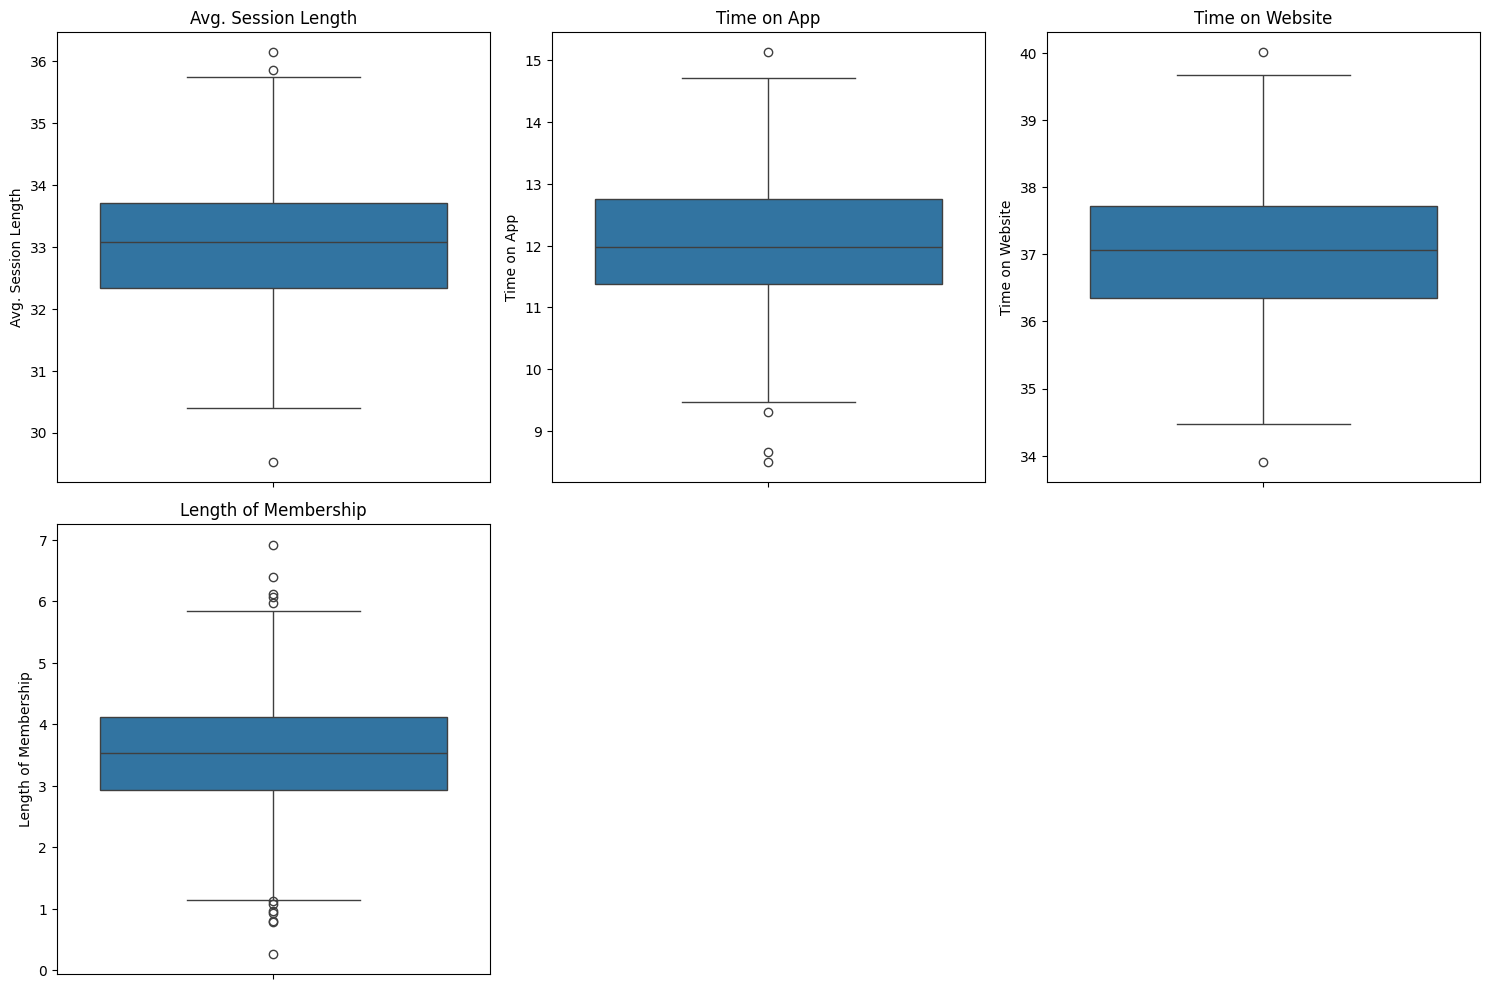

In [201]:
import seaborn as sns
import matplotlib.pyplot as plt

# variables predictoras (excluyendo la variable objetivo)
features = df.drop(["Yearly Amount Spent", "State"], axis=1)

# número de columnas de la grilla
cols = 3
rows = (len(features.columns) + cols - 1) // cols

plt.figure(figsize=(15, 10))

for i, col in enumerate(features.columns, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

También realizo visualización de la variable dependiente "Yeraly Amount Spent"

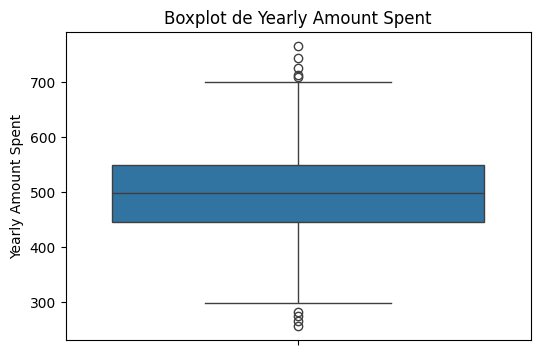

In [202]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Yearly Amount Spent"])
plt.title("Boxplot de Yearly Amount Spent")
plt.show()

In [203]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


Para comprobar el valor exacto de los outliers por varible, utilizo IQR.

In [204]:
import pandas as pd

# variables numéricas
numeric_cols = df.select_dtypes(include=['float64','int64']).columns

outliers_summary = {}

for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    outliers_summary[col] = len(outliers)

outliers_summary

{'Avg. Session Length': 3,
 'Time on App': 4,
 'Time on Website': 2,
 'Length of Membership': 12,
 'Yearly Amount Spent': 9}

In [205]:
outliers_df = pd.DataFrame(list(outliers_summary.items()),
                           columns=["Variable","Cantidad_Outliers"])

outliers_df

,Variable,Cantidad_Outliers
0,Avg. Session Length,3
1,Time on App,4
2,Time on Website,2
3,Length of Membership,12
4,Yearly Amount Spent,9


Para identificar valores atípicos se utilizó el método del rango intercuartílico (IQR). Este método considera como outliers aquellos valores que se encuentran por debajo de Q1 - 1.5× IQR o o por encima de Q3 + 1.5× IQR.
El análisis mostró que algunas variables presentan un número reducido de valores atípicos. Sin embargo, estos valores no fueron eliminados debido a que en datasets de comportamiento de clientes pueden representar variaciones reales dentro de la población analizada y no necesariamente errores en los datos. Por lo tanto, se decidió mantenerlos para no perder información relevante durante el entrenamiento del modelo.

Además, en este Dataset específico (Ecommerce Customers)  hay muy pocos outliers, lo cual explica porqué el modelo logró R² ≈ 0.98.

**Aplicar codiﬁcación a variables categóricas.**

Debido a que los algoritmos de aprendizaje automático solo pueden trabajar con datos numéricos, para incorporar la variable categórica State en el modelo se aplicó un proceso de codificación basado en One-Hot Encoding. Posteriormente se eliminó una de las categorías utilizando la opción drop_first=True, generando así variables dummy. Esta decisión se tomó para evitar el problema de multicolinealidad conocido como dummy variable trap, que puede afectar a modelos de regresión lineal cuando existe dependencia perfecta entre las variables explicativas.

Para no generar confusiones, se crea un nuevo df que incluye las variables dummy creadas para los States.

In [206]:
df_model=df.copy()
df_model = pd.get_dummies(df, columns=["State"], drop_first=True)

In [207]:
df_model

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent,State_AL,State_AR,State_AZ,State_CA,State_CO,...,State_TN,State_TX,State_UT,State_Unknown,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
0,34.497268,12.655651,39.577668,4.082621,587.951054,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,31.926272,11.109461,37.268959,2.664034,392.204933,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,33.000915,11.330278,37.110597,4.104543,487.547505,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3,34.305557,13.717514,36.721283,3.120179,581.852344,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,33.330673,12.795189,37.536653,4.446308,599.406092,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,33.237660,13.566160,36.417985,3.746573,573.847438,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
496,34.702529,11.695736,37.190268,3.576526,529.049004,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
497,32.646777,11.499409,38.332576,4.958264,551.620145,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
498,33.322501,12.391423,36.840086,2.336485,456.469510,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


Para incorporar la variable categórica State en el modelo se aplicó One-Hot Encoding, especificamente variables Dummy, técnica que transforma cada categoría en una variable binaria independiente. Esta elección se realizó debido a que los estados no presentan una relación ordinal entre sí, por lo que métodos como Label Encoding podrían inducir una interpretación errónea de jerarquía por parte del modelo. Al utilizar variables Dummies se evita introducir relaciones artificiales entre las categorías, permitiendo que el modelo de regresión lineal trate cada estado como una categoría independiente.

**Normalizar y/o estandarizar los datos.**

Con el objetivo de asegurar que todas las variables contribuyan de manera equilibrada al modelo, se aplicó un proceso de estandarización utilizando StandardScaler. Este método transforma las variables para que tengan media cero y desviación estándar uno, permitiendo que todas las variables se encuentren en una escala comparable.

Se utiliza StandardScaler para evitar el problema de data leakage, el escalador se ajustó únicamente utilizando los datos de entrenamiento (fit_transform), mientras que los datos de prueba se transformaron posteriormente usando los mismos parámetros (transform). Esto garantiza que la información del conjunto de prueba no influya en el proceso de entrenamiento del modelo.

Las variables numéricas fueron estandarizadas utilizando StandardScaler con el fin de garantizar que todas las variables continuas se encuentren en una escala comparable. Por otro lado, la variable categórica State fue transformada mediante One-Hot Encoding, generando variables dummy binarias (paso anterior). Estas variables no fueron escaladas debido a que ya se encuentran en un rango entre 0 y 1 y representan categorías discretas.

In [208]:
#Separo nuevamente variables predictoras y objetivo incluyendo ahora State
x = df_model.drop("Yearly Amount Spent", axis=1)
y = df_model["Yearly Amount Spent"]

In [209]:
#Defino variables numéricas y categóricas
numeric_cols = [
    "Avg. Session Length",
    "Time on App",
    "Time on Website",
    "Length of Membership"
]

cat_cols = [col for col in x.columns if col.startswith("State_")]

In [210]:
#Divido en entrenamiento y prueba
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [211]:
#Aplico estandarización solo a variables numéricas
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train[numeric_cols] = scaler.fit_transform(x_train[numeric_cols])
x_test[numeric_cols] = scaler.transform(x_test[numeric_cols])

In [212]:
#Verifico resultado
x_train.head(10)

,Avg. Session Length,Time on App,Time on Website,Length of Membership,State_AL,State_AR,State_AZ,State_CA,State_CO,State_CT,...,State_TN,State_TX,State_UT,State_Unknown,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
249,0.728756,-0.140376,-0.173216,0.065197,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
433,1.233670,-0.235492,-0.700765,-1.413095,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19,-0.449465,1.935961,0.166982,0.483620,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
322,0.206170,-1.328388,-0.860896,0.505068,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
332,0.084123,-0.321354,0.899668,-1.342230,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
56,-0.378128,1.707419,2.196177,-0.557475,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
301,-0.035305,1.131484,1.029286,-0.652411,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
229,0.897115,-1.076010,0.915706,-0.503947,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
331,-0.797430,0.898992,0.086611,0.118695,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
132,1.268054,-0.247652,0.387009,-1.066111,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Compruebo la estandarización, imprimiendo media y desviación standar de las variables estandarizadas.

In [213]:
#Compruebo escalamiento
x_train[numeric_cols].describe().loc[["mean","std"]]

,Avg. Session Length,Time on App,Time on Website,Length of Membership
mean,-2.997602e-15,7.438494e-16,-3.201883e-15,-5.329071e-17
std,1.001252e+00,1.001252e+00,1.001252e+00,1.001252e+00


Lo observo también graficamente como método de comprobación con variable "Time on Website"

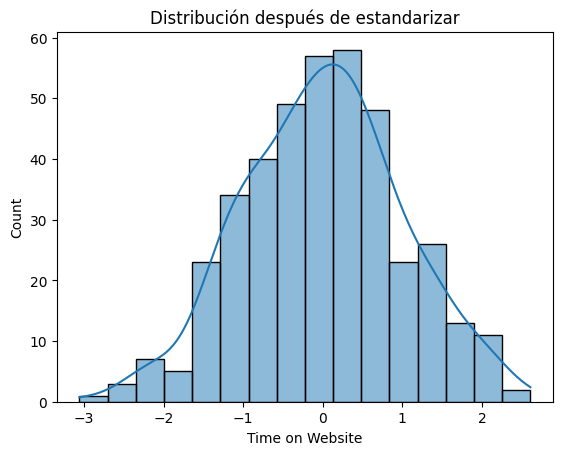

In [214]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(x_train["Time on Website"], kde=True)
plt.title("Distribución después de estandarizar")
plt.show()

Se realizó un proceso de estandarización de las variables numéricas utilizando el método StandardScaler, con el objetivo de que todas las variables se encuentren en una escala comparable antes del entrenamiento del modelo.

A partir de la tabla de estadísticas descriptivas del conjunto X_train, se observa que las variables presentan una media cercana a 0 y una desviación estándar cercana a 1, lo cual confirma que el proceso de estandarización se aplicó correctamente.

El gráfico complementa esta verificación, mostrando que los valores de las variables se distribuyen alrededor de cero y dentro de un rango acotado, lo que indica que no existen escalas desproporcionadas entre las variables.

Este procedimiento es importante porque muchos modelos de aprendizaje automático son sensibles a la escala de los datos. Al estandarizar las variables, se evita que aquellas con valores originalmente más grandes tengan una influencia desproporcionada en el entrenamiento del modelo.

**Si lo hago con PIPELINE**

In [215]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", "passthrough", cat_cols)
    ]
)
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

pipeline.fit(x_train, y_train)

X_train_pipeline = pipeline.named_steps["preprocessing"].transform(x_train)

X_train_pipeline


array([[ 0.72875642, -0.14037637, -0.17321599, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.23367035, -0.23549152, -0.70076461, ...,  0.        ,
         0.        ,  0.        ],
       [-0.44946538,  1.93596147,  0.16698241, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.26587083, -1.17327098, -2.08875055, ...,  0.        ,
         0.        ,  0.        ],
       [-0.81225043,  2.07956541,  0.00264921, ...,  0.        ,
         0.        ,  0.        ],
       [-0.64425634, -0.61010223,  0.55038981, ...,  0.        ,
         0.        ,  0.        ]], shape=(400, 54))

Compruebo que mediante la utilización de pipeline llego a los mismo resultados, siendo un método más ordenado y limpio

<b><font color= "red">Lección 4: Regresiones</b></font>                 
<b>Implementar un modelo de regresión y comprender su funcionamiento.</b>

**Entrenar un modelo de regresión lineal y uno polinomial.**

<b><font color= "red">Modelo 1: Regresión Lineal</b></font>     

In [216]:
lin_model = LinearRegression()

lin_model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [217]:
y_pred_lin = lin_model.predict(x_test)

**Evalúo el modelo**

En este punto es un nuevo modelo de regresión lineal, ya que ahora incluye la variable State para cada cliente

In [218]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lin = mean_absolute_error(y_test, y_pred_lin)
mse_lin = mean_squared_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print("MAE:", f"{mae_lin:.4f}")
print("MSE:", f"{mse_lin:.4f}")
print("RMSE:", f"{rmse_lin:.4f}")
print("R2:", f"{r2_lin:.4f}")

MAE: 9.5330
MSE: 142.5806
RMSE: 11.9407
R2: 0.9712


El modelo de regresión lineal presenta un buen desempeño predictivo para estimar el gasto anual de los clientes. El MAE de 9.53 indica que, en promedio, las predicciones del modelo se desvían alrededor de 9.5 dólares respecto a los valores reales. El RMSE de 11.94 muestra que los errores más grandes tienen una influencia moderada en el modelo, aunque siguen siendo relativamente bajos en relación con la escala de la variable objetivo. Además, el R² de 0.9712 señala que aproximadamente el 97.12% de la variabilidad del gasto anual es explicada por las variables independientes incluidas en el modelo. En conjunto, estos resultados sugieren que la regresión lineal logra capturar adecuadamente la relación entre las variables del dataset y el gasto anual de los clientes.

**Interpretar coeficientes**

In [219]:
coef_df = pd.DataFrame({
    "Variable": x_train.columns,
    "Coeficiente": lin_model.coef_
})

# Agregar el intercepto
intercept_df = pd.DataFrame({
    "Variable": ["Intercept"],
    "Coeficiente": [lin_model.intercept_]
})

coef_df = pd.concat([coef_df, intercept_df], ignore_index=True)

coef_df.sort_values(by="Coeficiente", ascending=False)

,Variable,Coeficiente
54,Intercept,502.551006
3,Length of Membership,63.689082
1,Time on App,38.795226
0,Avg. Session Length,24.805611
37,State_OH,13.239658
15,State_ID,7.852880
22,State_MD,6.221391
5,State_AR,6.051014
12,State_GA,5.892889
14,State_IA,5.446331


El análisis de los coeficientes del modelo de regresión lineal muestra que las variables asociadas al comportamiento del cliente son las que tienen mayor impacto en la predicción del gasto anual. En particular, Length of Membership presenta el coeficiente positivo más alto, lo que indica que una mayor antigüedad del cliente en la plataforma se asocia con un mayor gasto anual. Le siguen Time on App y Avg. Session Length, lo que sugiere que el uso activo de la aplicación también influye significativamente en el gasto. En contraste, Time on Website tiene un coeficiente cercano a cero, lo que indica un impacto muy reducido. Por otro lado, las variables dummy correspondientes al estado (State) presentan coeficientes relativamente pequeños en comparación con las variables principales, lo que sugiere que la ubicación geográfica tiene un efecto menor en la predicción del gasto anual. El intercepto del modelo representa el valor base estimado del gasto cuando las variables explicativas toman el valor cero.

**Observo gráficamente los valores reales versus las predicciones.**

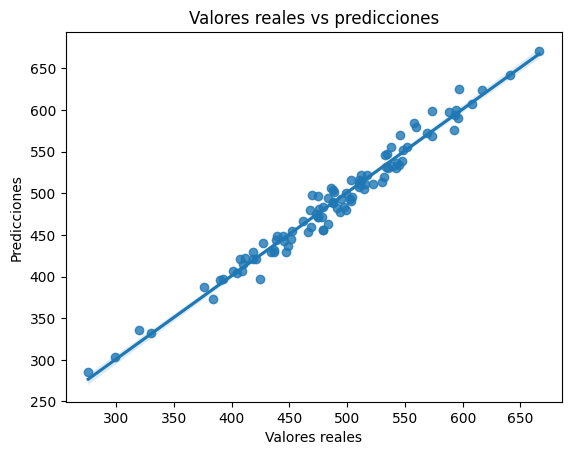

In [220]:
sns.regplot(x=y_test, y=y_pred_lin)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Valores reales vs predicciones")
plt.show()

El gráfico de valores reales versus predicciones permite evaluar visualmente el desempeño del modelo de regresión. Se observa que la mayoría de los puntos se concentran cerca de la diagonal esperada, lo que indica que las predicciones del modelo son bastante cercanas a los valores reales. Esto sugiere que el modelo logra capturar adecuadamente la relación entre las variables predictoras y el gasto anual de los clientes. En general, la dispersión observada es baja, lo que respalda el buen ajuste reflejado en las métricas de evaluación.


**Gráfica de residuos**

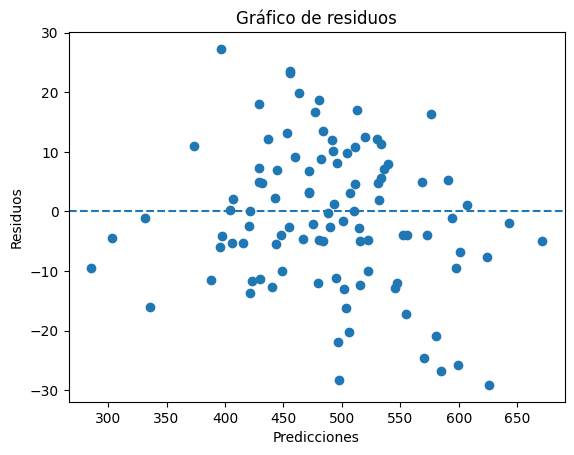

In [221]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred_lin

plt.scatter(y_pred_lin, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Gráfico de residuos")
plt.show()

El gráfico de residuos permite analizar la distribución de los errores del modelo. Se observa que los residuos se distribuyen alrededor de la línea cero sin mostrar un patrón sistemático claro, lo que sugiere que el modelo de regresión lineal captura adecuadamente la relación entre las variables. La dispersión relativamente uniforme de los puntos indica que los errores son aleatorios y no presentan tendencias evidentes.

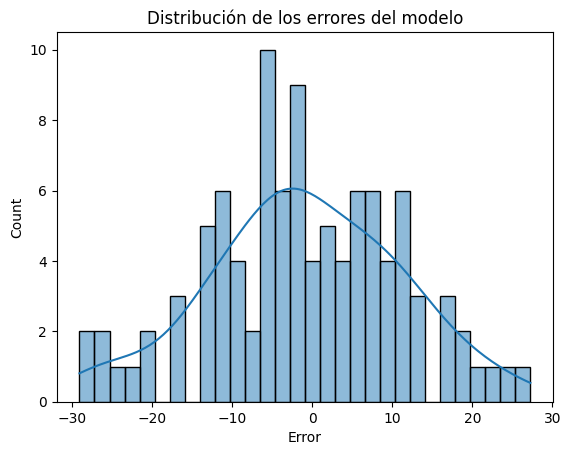

In [222]:
import seaborn as sns

sns.histplot(residuals, bins=30, kde=True)
plt.xlabel("Error")
plt.title("Distribución de los errores del modelo")
plt.show()

La distribución de los errores permite evaluar el comportamiento general de las predicciones del modelo. Se observa que los errores se concentran alrededor de cero y presentan una distribución aproximadamente simétrica, lo que indica que el modelo no presenta un sesgo sistemático en sus predicciones. Esto sugiere que, en promedio, las estimaciones del modelo son cercanas a los valores reales.

<b><font color= "red">Modelo 2: Regresión Polinomial</b></font>    

Ahora entreno un modelo de regresión polinomial 

Creo características polinómicas

In [223]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2,include_bias=False)

x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

Entreno modelo

In [224]:
poly_model = LinearRegression()

poly_model.fit(x_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [225]:
y_pred_poly = poly_model.predict(x_test_poly)

In [226]:
mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("MAE:", f"{mae_poly:.4f}")
print("MSE:", f"{mse_poly:.4f}")
print("RMSE:", f"{rmse_poly:.4f}")
print("R2:", f"{r2_poly:.4f}")

MAE: 18.4153
MSE: 871.7058
RMSE: 29.5247
R2: 0.8240


El modelo de regresión polinomial presenta un desempeño inferior al obtenido con la regresión lineal. El **MAE de 18.42** indica que, en promedio, las predicciones se desvían más del valor real en comparación con el modelo lineal. Asimismo, el **RMSE de 29.52** evidencia una mayor magnitud de error, especialmente en las predicciones más alejadas. El **R² de 0.8240** señala que el modelo explica aproximadamente el **82.4% de la variabilidad del gasto anual**, lo que representa una capacidad explicativa considerable, pero menor que la obtenida con el modelo lineal.


**Coeficientes del modelo**

In [227]:
poly_features = poly.get_feature_names_out(x_train.columns)

In [228]:
coef_poly_df = pd.DataFrame({
    "Variable": poly_features,
    "Coeficiente": poly_model.coef_
})
intercept_poly = pd.DataFrame({
    "Variable": ["Intercept"],
    "Coeficiente": [poly_model.intercept_]
})

coef_poly_df = pd.concat([coef_poly_df, intercept_poly], ignore_index=True)

coef_poly_df.sort_values(by="Coeficiente", ascending=False)


,Variable,Coeficiente
1539,Intercept,497.316821
197,Time on Website State_OK,87.829482
222,Length of Membership State_GA,64.404405
3,Length of Membership,49.341275
164,Time on Website State_AR,43.005342
...,...,...
90,Avg. Session Length State_NY,-15.863100
120,Time on App State_HI,-18.040613
151,Time on App State_TN,-30.726273
171,Time on Website State_GA,-33.439835


En el modelo de regresión polinomial se generan numerosas variables adicionales que representan interacciones y combinaciones entre las variables originales. Debido a este aumento significativo en el número de predictores, la interpretación individual de cada coeficiente se vuelve más compleja. Sin embargo, se observa que algunas interacciones entre variables de comportamiento del usuario y la ubicación geográfica presentan coeficientes elevados, lo que sugiere que el modelo intenta capturar relaciones más complejas entre estas variables y el gasto anual.

**Valores reales versus predicciones**

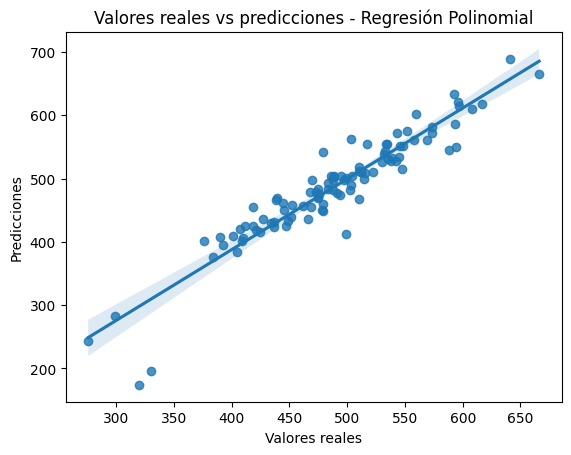

In [229]:
sns.regplot(x=y_test, y=y_pred_poly)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Valores reales vs predicciones - Regresión Polinomial")
plt.show()

El gráfico de valores reales frente a predicciones permite visualizar el ajuste del modelo polinomial. En comparación con el modelo lineal, se observa una mayor dispersión de los puntos respecto a la línea diagonal esperada, lo que indica que las predicciones presentan una mayor variabilidad respecto a los valores reales. Esto sugiere que el modelo polinomial no logra mejorar el ajuste y presenta un desempeño inferior al modelo de regresión lineal.

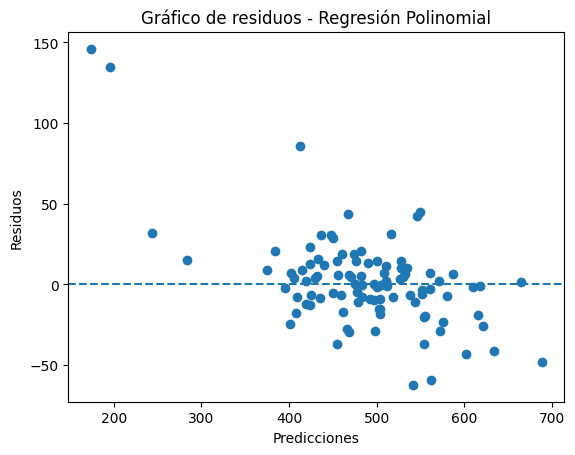

In [230]:
residuos_poly = y_test - y_pred_poly

plt.scatter(y_pred_poly, residuos_poly)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Gráfico de residuos - Regresión Polinomial")
plt.show()

El gráfico de residuos del modelo de regresión polinomial muestra la distribución de los errores respecto a las predicciones del modelo. Se observa una mayor dispersión de los residuos alrededor de la línea cero en comparación con el modelo lineal, lo que indica que el modelo presenta mayores errores de predicción. Esta mayor variabilidad sugiere que el modelo polinomial no logra capturar adecuadamente la relación entre las variables en este conjunto de datos.

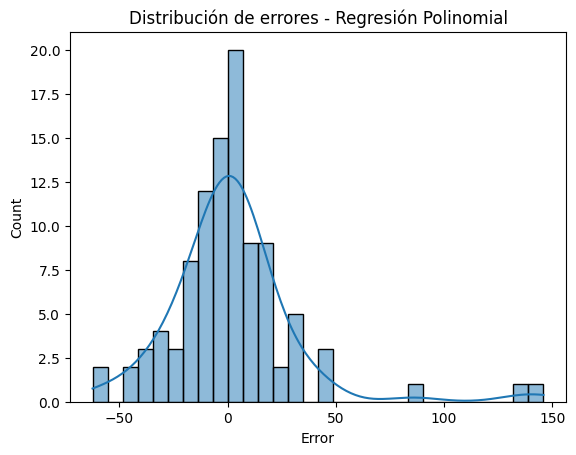

In [231]:
errores_poly = y_test - y_pred_poly

sns.histplot(errores_poly, bins=30, kde=True)
plt.xlabel("Error")
plt.title("Distribución de errores - Regresión Polinomial")
plt.show()

El histograma de errores del modelo polinomial permite observar la distribución de las diferencias entre los valores reales y los predichos. En este caso, los errores presentan una mayor dispersión y variabilidad, lo que refleja una menor precisión en las predicciones del modelo. Esto es consistente con las métricas de evaluación obtenidas, donde el modelo polinomial presenta un desempeño inferior al modelo de regresión lineal.

**Comparo ambos modelos, evaluando ajuste y precisión**

In [232]:
results = pd.DataFrame({
    "Modelo": ["Regresión Lineal", "Regresión Polinomial"],
    "MAE": [f"{mae_lin:.4f}", f"{mae_poly:.4f}"],
    "MSE": [f"{mse_lin:.4f}", f"{mse_poly:.4f}"],
    "RMSE": [f"{rmse_lin:.4f}", f"{rmse_poly:.4f}"],
    "R2": [f"{r2_lin:.4f}", f"{r2_poly:.4f}"]
})

results

,Modelo,MAE,MSE,RMSE,R2
0,Regresión Lineal,9.5330,142.5806,11.9407,0.9712
1,Regresión Polinomial,18.4153,871.7058,29.5247,0.8240


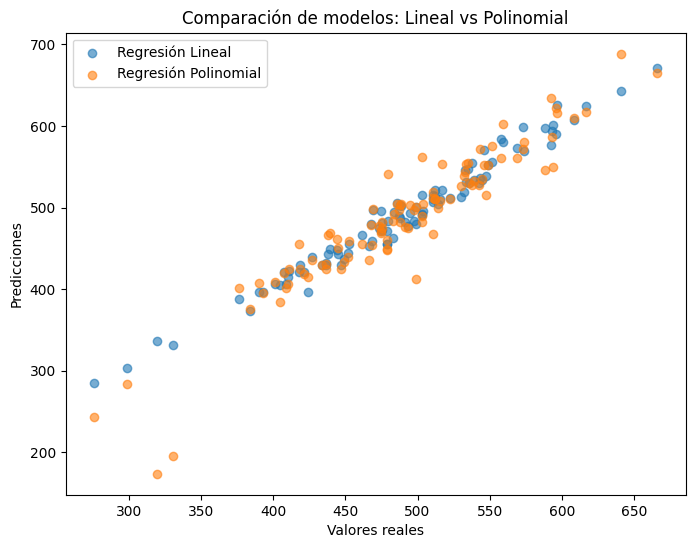

In [233]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_lin, alpha=0.6, label="Regresión Lineal")
plt.scatter(y_test, y_pred_poly, alpha=0.6, label="Regresión Polinomial")

plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Comparación de modelos: Lineal vs Polinomial")

plt.legend()
plt.show()

Se entrenaron dos modelos de regresión para predecir el gasto anual de los clientes: un modelo de regresión lineal y uno polinomial.
Al comparar las métricas de evaluación, ambos modelos presentan un desempeño similar, lo que sugiere que la relación entre las variables predictoras y la variable objetivo es principalmente lineal.
Por lo tanto, el modelo de regresión lineal resulta suficiente para capturar la relación entre las variables del dataset.                       

A partir de las métricas de evaluación y los gráficos obtenidos, es posible comparar el ajuste y la precisión de ambos modelos. La **regresión lineal** presenta un mejor desempeño, evidenciado por un **R² de 0.97**, lo que indica que explica aproximadamente el 97% de la variabilidad del gasto anual, además de mostrar menores errores (MAE y RMSE). En contraste, el **modelo polinomial** obtiene un **R² de 0.82** y errores considerablemente mayores, lo que refleja una menor precisión en las predicciones. Los gráficos de predicciones y residuos refuerzan este resultado, ya que el modelo lineal muestra puntos más cercanos a los valores reales y una menor dispersión de errores. En conjunto, estos resultados sugieren que la relación entre las variables es principalmente lineal, por lo que el modelo lineal resulta más adecuado para este conjunto de datos.


<b><font color= "red">Lección 5: Algoritmos de clasiﬁcación</b></font>                 
<b>Entender diferencias conceptuales con clasiﬁcación.</b>

**Analizar por qué un problema de clasiﬁcación no es adecuado para esta tarea.**

El problema analizado corresponde a una tarea de regresión, ya que la variable objetivo **Yearly Amount Spent** representa un valor numérico continuo que mide el gasto anual de los clientes. Los algoritmos de clasificación, en cambio, están diseñados para predecir **categorías o clases discretas** (por ejemplo, sí/no o alto/medio/bajo, deporte de preferencia). Utilizar un modelo de clasificación en este caso implicaría transformar artificialmente el gasto en categorías, lo que provocaría una pérdida de información y una menor precisión en las predicciones. Por esta razón, los modelos de regresión resultan más apropiados para este tipo de problema.

**Implementar un clasiﬁcador KNN sobre un subconjunto simulado.**

In [234]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score

Para la implementación del modelo de clasificación se utilizó el dataset "Student Performance Dataset", disponible en el UCI Machine Learning Repository. Este conjunto de datos contiene información académica, social y demográfica de estudiantes de educación secundaria en Portugal, recopilada con el objetivo de analizar los factores que influyen en el rendimiento académico. El dataset cuenta con aproximadamente 395 observaciones y diversas variables que describen el contexto educativo de cada estudiante. Entre las variables más relevantes se encuentran la edad del estudiante (age), el tiempo dedicado al estudio semanal (studytime), el número de cursos reprobados previamente (failures), la cantidad de ausencias a clases (absences), y las calificaciones obtenidas en diferentes periodos del curso (G1, G2 y G3). Estas últimas representan las notas del primer periodo, segundo periodo y la calificación final del curso respectivamente, las cuales se encuentran expresadas en una escala de 0 a 20 puntos, donde valores más altos indican un mejor desempeño académico.

En el dataset original, la variable G3 corresponde a la nota final del estudiante y se presenta como una variable numérica continua. Sin embargo, para aplicar un modelo de clasificación es necesario contar con una variable objetivo categórica. Por esta razón, se realizó una transformación de la variable G3 con el objetivo de generar una nueva variable llamada resultado académico, la cual permite clasificar a los estudiantes según su desempeño final. Esta transformación se realizó utilizando un criterio común en muchos sistemas educativos, donde una calificación igual o superior a 10 puntos se considera aprobatoria, mientras que una calificación inferior a este valor se considera reprobatoria. De esta manera, se definieron dos categorías: “Aprobado”, correspondiente a estudiantes con una nota final mayor o igual a 10, y “Reprobado”, correspondiente a estudiantes con una nota final menor a 10.

La transformación de la variable G3 permite convertir el problema original en un problema de clasificación binaria, donde el objetivo del modelo es predecir si un estudiante aprobará o reprobará el curso en función de sus características académicas y su comportamiento escolar. Este tipo de transformación es necesaria para poder aplicar algoritmos de clasificación supervisada, como el modelo K-Nearest Neighbors (KNN), los cuales requieren que la variable objetivo se encuentre expresada en categorías. Además, esta conversión facilita la interpretación de los resultados, ya que clasificar a los estudiantes en aprobado o reprobado representa una situación académica clara y fácilmente comprensible. Asimismo, transformar una variable continua en categorías permite simplificar el problema analítico, lo que resulta útil para comprender el funcionamiento del algoritmo de clasificación y analizar cómo las distintas variables influyen en la predicción del resultado académico. En este contexto, variables como la edad, el tiempo de estudio, el número de reprobaciones previas, las ausencias y las calificaciones parciales pueden ser utilizadas por el modelo para identificar patrones en los datos y determinar la probabilidad de que un estudiante pertenezca a una de las dos clases definidas.

**Tabla de variables**

| Variable  | Tipo     | Descripción             |
| --------- | -------- | ----------------------- |
| age       | numérica | edad del estudiante     |
| studytime | numérica | horas de estudio        |
| failures  | numérica | número de reprobaciones |
| absences  | numérica | ausencias               |
| G1        | numérica | nota primer periodo     |
| G2        | numérica | nota segundo periodo    |
| G3        | numérica | nota final              |


Cargo el dataset y creo variable de clasificación

In [235]:
# cargar dataset
df_knn = pd.read_csv("student-mat.csv", sep=";")

# crear variable de clasificación
df_knn["resultado"] = df_knn["G3"].apply(lambda x: "Aprobado" if x >= 10 else "Reprobado")

**Realizo un pequeño análisis exploratorio de los datos**

In [236]:
df_knn

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,resultado
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,Reprobado
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,Reprobado
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,Aprobado
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,Aprobado
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,Aprobado
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,4,4,5,4,11,9,9,9,Reprobado
391,MS,M,17,U,LE3,T,3,1,services,services,...,4,5,3,4,2,3,14,16,16,Aprobado
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,3,3,3,3,3,10,8,7,Reprobado
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,1,3,4,5,0,11,12,10,Aprobado


Verifico valores nulos y tipo de datos

In [237]:
df_knn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

Verifico distribución de la variable objetivo

In [238]:
#Distribución de la variable objetivo
df_knn["resultado"].value_counts()

resultado
Aprobado     265
Reprobado    130
Name: count, dtype: int64

**Realizo una exploración de la relaciones existentes entre las variables**

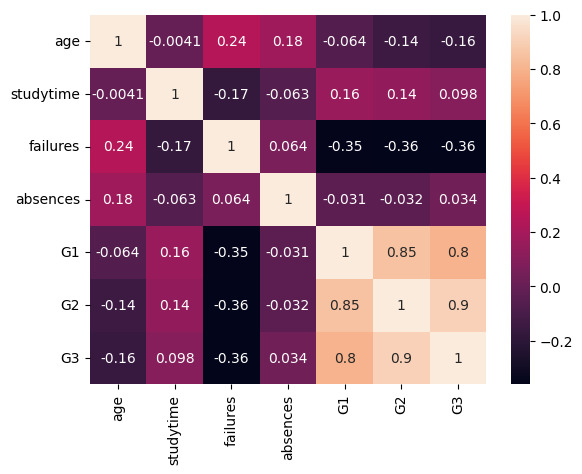

In [239]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_knn[["age","studytime","failures","absences","G1","G2","G3"]].corr()

sns.heatmap(corr, annot=True)
plt.show()

La matriz de correlación muestra una fuerte relación entre las variables G1, G2 y G3, lo cual es esperable ya que corresponden a evaluaciones del mismo estudiante en distintos momentos del curso. Esta alta correlación indica que las calificaciones parciales son buenos indicadores del rendimiento final. En modelos como KNN, donde se utilizan distancias entre observaciones, variables altamente correlacionadas pueden aportar información similar y aumentar su influencia en el cálculo de dichas distancias. Por ello, es importante considerar esta relación al interpretar los resultados del modelo.

**Análisis del valor K**

Para seleccionar un valor adecuado del parámetro K se utilizó validación cruzada de 5 folds, evaluando el rendimiento del modelo para distintos valores de vecinos. Este procedimiento permite estimar de forma más robusta el desempeño del modelo, ya que cada observación es utilizada tanto para entrenamiento como para validación en diferentes iteraciones. A partir de este análisis se identificó el valor de K que obtiene el mayor rendimiento promedio

In [240]:
# variables
X = df_knn[["age", "studytime", "failures", "absences", "G1", "G2"]]
y = df_knn["resultado"]

# dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

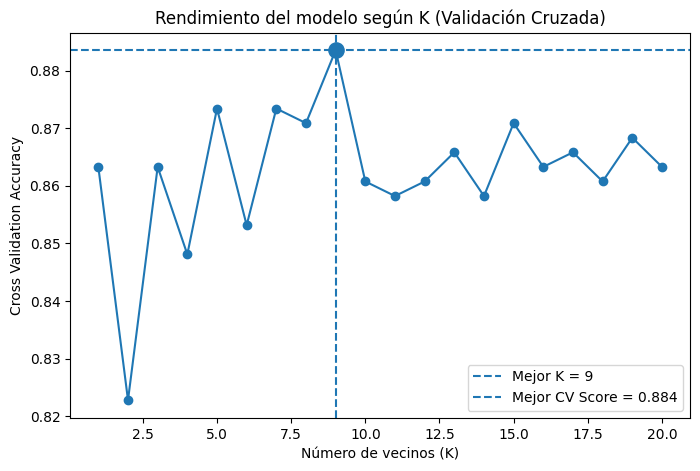

Mejor K según Cross Validation: 9
Mejor CV Score: 0.8835443037974684


In [241]:
k_values = range(1, 21)
cv_scores = []

for k in k_values:
    
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    
    scores = cross_val_score(pipeline, X, y, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

# mejor K y mejor score
best_index = np.argmax(cv_scores)
best_k = k_values[best_index]
best_score = cv_scores[best_index]

# gráfico
plt.figure(figsize=(8,5))

plt.plot(k_values, cv_scores, marker='o')

# marcar mejor punto
plt.scatter(best_k, best_score, s=120)

# líneas de referencia
plt.axvline(best_k, linestyle="--", label=f"Mejor K = {best_k}")
plt.axhline(best_score, linestyle="--", label=f"Mejor CV Score = {best_score:.3f}")

plt.xlabel("Número de vecinos (K)")
plt.ylabel("Cross Validation Accuracy")
plt.title("Rendimiento del modelo según K (Validación Cruzada)")

plt.legend()
plt.show()

print("Mejor K según Cross Validation:", best_k)
print("Mejor CV Score:", best_score)

Evalúo, para distintos k, accuracy y recall de los Reprobados

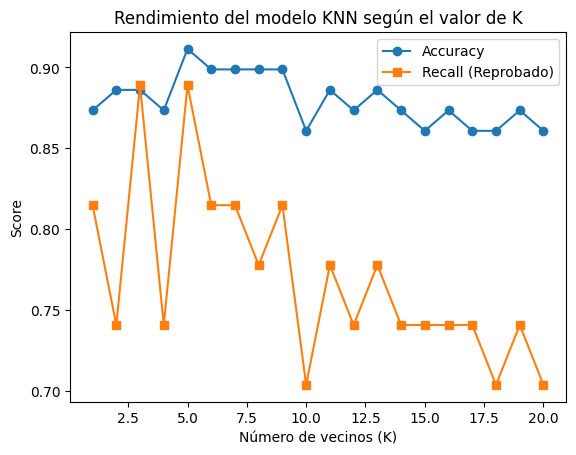

In [242]:
from sklearn.metrics import accuracy_score, recall_score

k_values = range(1, 21)

accuracy_scores = []
recall_scores = []

for k in k_values:
    
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    
    accuracy_scores.append(accuracy_score(y_test, y_pred))
    
    # recall para detectar estudiantes reprobados
    recall_scores.append(recall_score(y_test, y_pred, pos_label="Reprobado"))

# gráfico
plt.figure()

plt.plot(k_values, accuracy_scores, marker='o', label="Accuracy")
plt.plot(k_values, recall_scores, marker='s', label="Recall (Reprobado)")

plt.xlabel("Número de vecinos (K)")
plt.ylabel("Score")
plt.title("Rendimiento del modelo KNN según el valor de K")

plt.legend()

plt.show()

Aunque las métricas de accuracy y recall alcanzan su valor máximo en K = 5, el rendimiento del modelo se mantiene relativamente estable entre K = 6 y K = 9. Al aplicar validación cruzada, el mejor desempeño promedio se obtiene con K = 9, lo que sugiere que este valor ofrece una estimación más robusta y menos dependiente de una única división del dataset. Por esta razón, se seleccionó K = 9 como el valor final del parámetro. Esto sin perjuicio de otras elecciones que podrían tomar otros analistas.

Asimismo, la selección de K = 9 permite que la predicción del modelo se base en un grupo más amplio de estudiantes con características similares, lo que genera decisiones más estables y menos sensibles a casos individuales. Esto es relevante en el contexto educativo, ya que el objetivo es identificar de manera confiable a estudiantes en riesgo de reprobar, permitiendo detectar patrones más representativos del comportamiento académico y facilitando la implementación de estrategias de apoyo oportunas.

**Se aplica el algoritmo KNN**

Se seleccionan las variables, se dividen los datos entre entrenamiento y prueba, luego se escalan los datos, para esto, se utilizó estandarización Z-score para escalar las variables antes de aplicar el modelo KNN, ya que este algoritmo se basa en el cálculo de distancias entre observaciones. La estandarización permite que todas las variables tengan media 0 y desviación estándar 1, evitando que aquellas con valores más grandes influyan desproporcionadamente en el cálculo de la distancia. De esta manera, cada variable contribuye de forma equilibrada al modelo. Además, este método suele ser más estable que Min-Max cuando los datos presentan variaciones o posibles valores extremos. Finalmente se entrena el modelo y se realiza la predicción.

In [243]:
# crear pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=9))  # k elegido de acuerdo al análisis
])

# entrenar modelo
pipeline.fit(X_train, y_train)

# predicción
y_pred = pipeline.predict(X_test)

cm_knn9=confusion_matrix(y_test, y_pred)

# resultados
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nMatriz de confusión:\n", cm_knn9)
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.8987341772151899

Matriz de confusión:
 [[49  3]
 [ 5 22]]

Reporte de clasificación:

              precision    recall  f1-score   support

    Aprobado       0.91      0.94      0.92        52
   Reprobado       0.88      0.81      0.85        27

    accuracy                           0.90        79
   macro avg       0.89      0.88      0.89        79
weighted avg       0.90      0.90      0.90        79



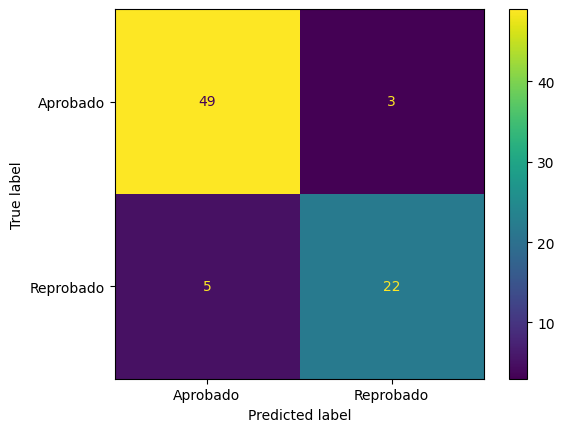

In [244]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

El modelo KNN obtuvo un accuracy de 0.8987, lo que indica que aproximadamente el 90% de las observaciones del conjunto de prueba fueron clasificadas correctamente. Este resultado muestra que el modelo mantiene un buen desempeño general al distinguir entre estudiantes aprobados y reprobados.

Al analizar la matriz de confusión, se observa que el modelo clasificó correctamente 49 estudiantes que aprobaron y 22 que reprobaron. Por otro lado, se registran 3 casos en los que estudiantes aprobados fueron clasificados como reprobados y 5 casos en los que estudiantes reprobados fueron clasificados como aprobados. En total, el modelo comete 8 errores sobre 79 observaciones, lo que explica el accuracy cercano al 90% obtenido en el conjunto de prueba.

En cuanto a las métricas del reporte de clasificación, la clase “Aprobado” presenta una precisión de 0.91, lo que significa que cuando el modelo predice que un estudiante aprobó, en el 91% de los casos la predicción es correcta. El recall de 0.94 indica que el modelo logra identificar correctamente el 94% de los estudiantes que realmente aprobaron, lo que muestra una buena capacidad para detectar esta clase. El F1-score de 0.92 refleja un equilibrio adecuado entre precisión y recall.

Para la clase “Reprobado”, la precisión es de 0.88, lo que indica que la mayoría de los estudiantes clasificados como reprobados efectivamente pertenecen a esta categoría. Sin embargo, el recall de 0.81 muestra que el modelo identifica correctamente el 81% de los estudiantes que realmente reprobaron, lo que implica que algunos casos de reprobación son clasificados como aprobados. El F1-score de 0.85 refleja un desempeño ligeramente menor en comparación con la clase “Aprobado”.

En conjunto, estos resultados muestran que el modelo mantiene un buen desempeño general, aunque presenta una ligera tendencia a identificar con mayor precisión a los estudiantes que aprueban que a aquellos que reprueban. A pesar de esta diferencia, las métricas siguen siendo relativamente equilibradas y el modelo demuestra una capacidad adecuada de generalización sobre los datos de prueba.

Aunque el modelo con K = 5 presentó un accuracy ligeramente mayor, el análisis mediante validación cruzada mostró que valores de K cercanos, particularmente K = 9, ofrecen un rendimiento más estable a lo largo de diferentes particiones del dataset. Esto explica la leve variación observada en el accuracy final, que disminuye ligeramente pero mantiene un desempeño general alto. En este contexto, la selección del hiperparámetro no debe basarse únicamente en el valor máximo de accuracy obtenido en un único conjunto de prueba, sino también en la estabilidad y consistencia del modelo, aspectos que la validación cruzada permite evaluar de forma más robusta

*Para visualizar el comportamiento del modelo KNN se representaron las fronteras de decisión utilizando dos variables del dataset G1 y G2. Este gráfico muestra cómo el modelo divide el espacio de características en regiones donde predice cada una de las clases. Las fronteras se generan a partir de la proximidad entre observaciones, ya que el algoritmo clasifica cada punto según la clase predominante entre sus vecinos más cercanos.*

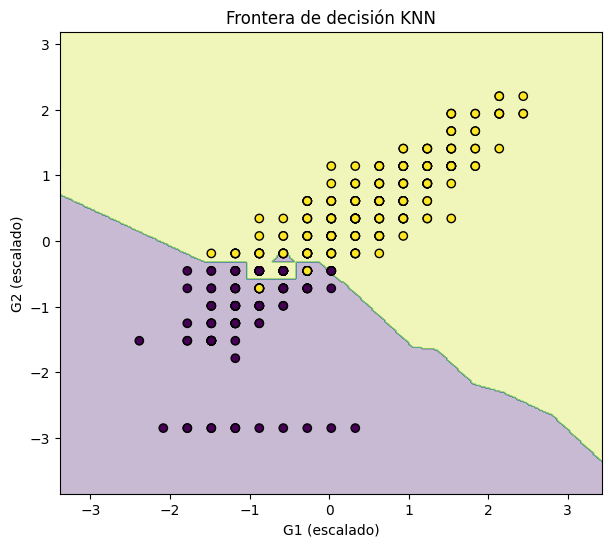

In [245]:
# usar solo 2 variables
X = df_knn[["G1","G2"]]
y = df_knn["resultado"]

# convertir clases a números
y_encoded, labels = pd.factorize(y)

# escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# modelo
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_scaled, y_encoded)

# crear malla
x_min, x_max = X_scaled[:,0].min()-1, X_scaled[:,0].max()+1
y_min, y_max = X_scaled[:,1].min()-1, X_scaled[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# gráfico
plt.figure(figsize=(7,6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=y_encoded,
    edgecolor="k"
)

plt.xlabel("G1 (escalado)")
plt.ylabel("G2 (escalado)")
plt.title("Frontera de decisión KNN")
plt.show()

**Comparar su comportamiento frente al modelo regresivo.**

Para complementar el análisis, se implementó un modelo de clasificación KNN con el objetivo de predecir si un estudiante aprueba o reprueba el curso a partir de distintas variables académicas y personales. Este ejercicio permitió observar cómo los algoritmos de clasificación pueden identificar patrones en los datos y asignar observaciones a categorías específicas.
Sin embargo, es importante destacar que este modelo resuelve un problema de clasificación, en el cual el objetivo consiste en asignar cada observación a una categoría específica. En contraste, el objetivo principal del proyecto de e-commerce consiste en predecir el monto promedio de compra de un cliente, lo cual corresponde a una variable numérica continua.

En este contexto, los modelos de regresión resultan más adecuados, ya que permiten estimar valores numéricos y analizar cómo las variables explicativas influyen en la magnitud de la variable objetivo. A diferencia de los modelos de clasificación, que predicen categorías discretas, los modelos de regresión generan predicciones continuas que pueden representar montos de gasto o ingresos esperados.

Por lo tanto, aunque el modelo KNN de clasificación permite comprender el funcionamiento de los algoritmos supervisados y analizar el comportamiento de los datos en un problema categórico, el enfoque más apropiado para el objetivo del proyecto es el uso de modelos de regresión, los cuales permiten estimar directamente el valor esperado de compra de cada cliente.

<b><font color= "red">Lección 6: Métricas de desempeño</b></font>                 
<b>Evaluar objetivamente el rendimiento del modelo regresivo.</b>

En esta sección se presentan las métricas de desempeño de los modelos entrenados con el objetivo de evaluar de manera objetiva su capacidad predictiva. Cabe destacar que la mayor parte de estos cálculos ya fue realizada en la Lección 4, durante el proceso de entrenamiento y evaluación inicial de los modelos de regresión lineal y polinomial. Por esta razón, en la presente lección el énfasis se centra principalmente en **organizar y comparar las métricas obtenidas**, así como en **explicar brevemente su significado**. Esto permite sintetizar los resultados del análisis y determinar de forma clara cuál de los modelos presenta un mejor desempeño en la predicción del gasto anual de los clientes.


**Tabla comparativa de métricas**

In [246]:
results = pd.DataFrame({
    "Modelo": ["Regresión Lineal", "Regresión Polinomial"],
    "MAE": [mae_lin, mae_poly],
    "MSE": [mse_lin, mse_poly],
    "RMSE": [rmse_lin, rmse_poly],
    "R2": [r2_lin, r2_poly]
})

results.round(4)

,Modelo,MAE,MSE,RMSE,R2
0,Regresión Lineal,9.5330,142.5806,11.9407,0.9712
1,Regresión Polinomial,18.4153,871.7058,29.5247,0.8240


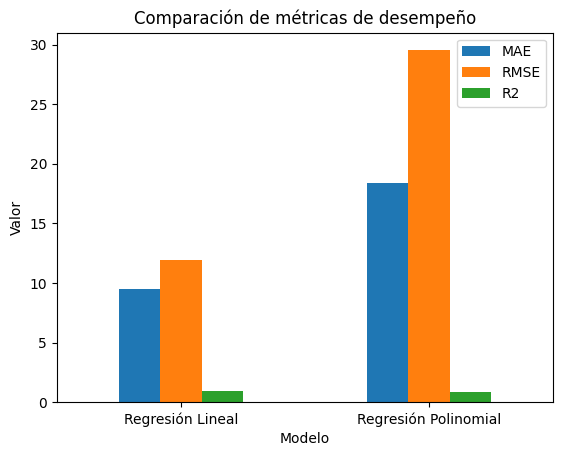

In [247]:
results.set_index("Modelo")[["MAE","RMSE","R2"]].plot(kind="bar")

plt.title("Comparación de métricas de desempeño")
plt.ylabel("Valor")
plt.xticks(rotation=0)
plt.show()


Las métricas de desempeño permiten evaluar de manera objetiva la capacidad predictiva de los modelos entrenados. Al comparar los resultados, se observa que la regresión lineal presenta valores considerablemente menores en MAE, MSE y RMSE, lo que indica que sus predicciones tienen errores promedio más bajos. Además, el coeficiente de determinación (R²) alcanza un valor cercano a 0.97, lo que significa que el modelo logra explicar aproximadamente el 97% de la variabilidad del gasto anual. En contraste, el modelo de regresión polinomial presenta errores más elevados y un R² menor, lo que evidencia un ajuste inferior. En conjunto, estos resultados confirman que el modelo de regresión lineal ofrece un mejor desempeño para este conjunto de datos.

**Se hace presente que la interpretación de las métricas para cada modelo regresivo se realizó en la lección 4, así como los gráficos de residuos, valores reales vs predicciones y distribución de errores de cada modelo.**


<b><font color= "red">Lección 7: Optimización del modelo</b></font>                 
<b>Mejorar el desempeño general del modelo mediante técnicas de ajuste.</b>

**Realizar ingeniería de características**

En las etapas previas del proyecto ya se aplicaron diversas técnicas que forman parte de la ingeniería de características. En particular, se realizó la transformación de variables categóricas mediante codificación dummy para la variable **State**, así como la generación de variables polinomiales para explorar relaciones más complejas entre los predictores. Además, a partir del análisis de los coeficientes del modelo de regresión lineal desarrollado en las lecciones anteriores, se observó que muchas de las variables asociadas al estado presentan coeficientes de baja magnitud, lo que sugiere un aporte limitado al modelo. Por esta razón, en esta sección se explorará la selección de variables como una estrategia de optimización, evaluando si la eliminación de características poco relevantes permite simplificar el modelo sin afectar significativamente su desempeño predictivo.


■ **Realizar ingeniería de características**      

■ **Ajustar hiperparámetros usando GridSearchCV**       

■ **Aplicar regularización (Ridge, Lasso) y observar su impacto**             

Para mejorar el desempeño del modelo se aplicó una búsqueda de hiperparámetros mediante GridSearchCV, una técnica que evalúa sistemáticamente distintas combinaciones de parámetros utilizando validación cruzada. En este caso, se utilizó para encontrar el valor óptimo del parámetro alpha en los modelos de regularización Ridge y Lasso, probando diferentes niveles de penalización sobre los coeficientes del modelo. Este procedimiento permitió identificar la configuración que maximiza el desempeño predictivo según la métrica R2, reduciendo el riesgo de sobreajuste y mejorando la capacidad de generalización del modelo.

Para modelos de regresión regularizada como Ridge y Lasso, el hiperparámetro más relevante es alpha, ya que controla la intensidad de la penalización aplicada a los coeficientes del modelo y, por lo tanto, el nivel de regularización. Este parámetro influye directamente en el equilibrio entre ajuste del modelo y capacidad de generalización. Por esta razón, en el proceso de optimización mediante GridSearchCV se decidió ajustar únicamente alpha, ya que otros parámetros como fit_intercept, max_iter o tol suelen tener un impacto menor en el desempeño del modelo en comparación con la fuerza de la regularización.

El parámetro **α** controla la intensidad de la regularización aplicada al modelo. Valores más altos implican una mayor penalización sobre la magnitud de los coeficientes. En el caso de Ridge, la regularización reduce el tamaño de los coeficientes sin eliminarlos completamente, permitiendo controlar la complejidad del modelo. Por su parte, Lasso puede reducir algunos coeficientes exactamente a cero, lo que equivale a eliminar variables del modelo y realizar una selección automática de características. Esto permite identificar qué variables tienen menor relevancia en la predicción del gasto anual.

<u>Creo nuevamente el split, ya que se han creado varios modelos, así no se genera confusión</u>

In [248]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

x = df_model.drop("Yearly Amount Spent", axis=1)
y = df_model["Yearly Amount Spent"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
# Pipeline
pipeline_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

# Hiperparámetros a probar
param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

# GridSearch
grid = GridSearchCV(
    pipeline_ridge,
    param_grid,
    cv=5,
    scoring="r2"
)

# Entrenamiento
grid.fit(x_train, y_train)

print("Mejor parámetro:", grid.best_params_)
print("Mejor R2:", grid.best_score_)

Mejor parámetro: {'model__alpha': 1}
Mejor R2: 0.9821458469719755


In [249]:
best_ridge = grid.best_estimator_
y_pred_ridge = best_ridge.predict(x_test)

In [250]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("MAE:", mae_ridge)
print("MSE:", mse_ridge)
print("RMSE:", rmse_ridge)
print("R2:", r2_ridge)

MAE: 9.526197343245057
MSE: 141.99911234248447
RMSE: 11.9163380424728
R2: 0.9713233380073124


**¿Qué hizo Ridge?**

In [251]:
coef_ridge = pd.DataFrame({
    "Variable": x_train.columns,
    "Coeficiente_Ridge": best_ridge.named_steps["model"].coef_
})

coef_ridge.sort_values(by="Coeficiente_Ridge", key=abs, ascending=False)

,Variable,Coeficiente_Ridge
3,Length of Membership,63.518559
1,Time on App,38.697732
0,Avg. Session Length,24.742795
37,State_OH,0.948304
33,State_NJ,-0.899448
47,State_Unknown,-0.879747
21,State_MA,-0.789467
41,State_RI,-0.748056
49,State_VT,0.712655
5,State_AR,0.702424


Se observa una leve disminución de los coeficientes del modelo.     
En cuanto al valor de R² obtenido mediante GridSearchCV corresponde al promedio del desempeño del modelo durante la validación cruzada realizada sobre el conjunto de entrenamiento. Posteriormente, el modelo optimizado fue evaluado sobre el conjunto de prueba, obteniendo un R² ligeramente menor. Esta diferencia es esperable, ya que el conjunto de test contiene datos que el modelo no utilizó durante el entrenamiento, lo que permite evaluar su capacidad de generalización.

**Modelo Lasso**

In [252]:
from sklearn.linear_model import Lasso

pipeline_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso())
])
param_grid_lasso = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10]
}

grid_lasso = GridSearchCV(
    pipeline_lasso,
    param_grid_lasso,
    cv=5,
    scoring="r2"
)

grid_lasso.fit(x_train, y_train)

print(grid_lasso.best_params_)

{'model__alpha': 1}


Predicción Lasso

In [253]:
best_lasso = grid_lasso.best_estimator_

y_pred_lasso = best_lasso.predict(x_test)

In [254]:
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("MAE Lasso:", mae_lasso)
print("MSE Lasso:", mse_lasso)
print("RMSE Lasso:", rmse_lasso)
print("R2 Lasso:", r2_lasso)

MAE Lasso: 8.576127101603566
MSE Lasso: 110.64282318095076
RMSE Lasso: 10.518689233024748
R2 Lasso: 0.9776557276314217


**¿Qué hizo Lasso?**

In [255]:
coef_lasso = pd.DataFrame({
    "Variable": x_train.columns,
    "Coeficiente_Lasso": best_lasso.named_steps["model"].coef_
})

coef_lasso.sort_values(by="Coeficiente_Lasso", key=abs, ascending=False)

,Variable,Coeficiente_Lasso
3,Length of Membership,62.612093
1,Time on App,37.747221
0,Avg. Session Length,24.254503
37,State_OH,0.034660
4,State_AL,-0.000000
2,Time on Website,0.000000
6,State_AZ,0.000000
7,State_CA,0.000000
8,State_CO,-0.000000
9,State_CT,-0.000000


<u>Lasso eliminó los coeficientes de las variables Time on Website y State</u>

No se aplicaron técnicas de regularización (Ridge o Lasso) al modelo polinomial debido a que su desempeño fue significativamente inferior al modelo lineal, lo que sugiere que la relación entre las variables predictoras y la variable objetivo es predominantemente lineal. En este contexto, incrementar la complejidad del modelo mediante transformaciones polinomiales generó un aumento considerable en el número de variables y un deterioro en las métricas de desempeño, evidenciando un posible sobreajuste. Por esta razón, la optimización mediante regularización se enfocó en el modelo lineal, que ya presentaba un alto poder predictivo, permitiendo evaluar si era posible mejorar su capacidad de generalización sin introducir complejidad innecesaria.

**Tabla comparativa modelos**

In [256]:
tabla_modelos = pd.DataFrame({
    "Modelo": ["Lineal", "Polinomial", "Ridge", "Lasso"],
    "MAE": [mae_lin, mae_poly, mae_ridge, mae_lasso],
    "RMSE": [rmse_lin, rmse_poly, rmse_ridge, rmse_lasso],
    "R2": [r2_lin, r2_poly, r2_ridge, r2_lasso]
})

tabla_modelos.round(4)

,Modelo,MAE,RMSE,R2
0,Lineal,9.5330,11.9407,0.9712
1,Polinomial,18.4153,29.5247,0.8240
2,Ridge,9.5262,11.9163,0.9713
3,Lasso,8.5761,10.5187,0.9777


<u>Interpretación de resultados</u>

Los resultados muestran que el modelo de regresión lineal presenta un desempeño muy alto, con un R2 de 0.9712 y errores relativamente bajos (MAE ≈ 9.53 y RMSE ≈ 11.94), lo que indica que explica gran parte de la variabilidad del gasto anual de los clientes. En contraste, el modelo polinomial obtiene un rendimiento considerablemente inferior, con un R2 de 0.8240 y errores más elevados, lo que sugiere que aumentar la complejidad del modelo no mejora la capacidad predictiva para este conjunto de datos. Al aplicar regularización, el modelo Ridge muestra un desempeño muy similar al lineal, mientras que Lasso logra mejorar ligeramente las métricas, reduciendo los errores y aumentando el R2 hasta 0.9777, lo que indica un mejor ajuste y posiblemente una selección más eficiente de variables.

**Conclusión**

En conjunto, los resultados sugieren que la relación entre las variables predictoras y el gasto anual es principalmente lineal, por lo que modelos más complejos como la regresión polinomial no aportan mejoras y pueden incluso perjudicar el rendimiento. La aplicación de regularización, especialmente mediante Lasso, permite mejorar levemente la capacidad predictiva del modelo al reducir la influencia de variables poco relevantes. Por lo tanto, el modelo Lasso se posiciona como la mejor alternativa entre los evaluados, ya que combina un alto poder explicativo con menores errores de predicción y una mayor capacidad de generalización.

<font color=red>Aplicación Grid a algoritmo KNN realizado en lección 5</font>

In [257]:
# variables
X = df_knn[["age", "studytime", "failures", "absences", "G1", "G2"]]
y = df_knn["resultado"]

# dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)



In [258]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "knn__n_neighbors": [3,5,7,9,11,15],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor accuracy:", grid.best_score_)

Mejores parámetros: {'knn__metric': 'manhattan', 'knn__n_neighbors': 15, 'knn__weights': 'uniform'}
Mejor accuracy: 0.8987103174603174


Se entrena el modelo aplicando los parámetros obtenidos con Grid

In [259]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# pipeline con los mejores parámetros
pipeline_knn_grid = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=15,
        metric="manhattan",
        weights="uniform"
    ))
])

# entrenar modelo
pipeline_knn_grid.fit(X_train, y_train)

# predicciones
y_pred_grid = pipeline_knn_grid.predict(X_test)

# accuracy general
print("Accuracy:", accuracy_score(y_test, y_pred_grid))

# matriz de confusión
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_grid))

# métricas completas por clase
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_grid))

Accuracy: 0.8734177215189873

Matriz de confusión:
[[49  3]
 [ 7 20]]

Reporte de clasificación:
              precision    recall  f1-score   support

    Aprobado       0.88      0.94      0.91        52
   Reprobado       0.87      0.74      0.80        27

    accuracy                           0.87        79
   macro avg       0.87      0.84      0.85        79
weighted avg       0.87      0.87      0.87        79



**Comparativa el modelo knn con k=9 y modelo knn=15 (resultados obtenidos con GridSearch)**

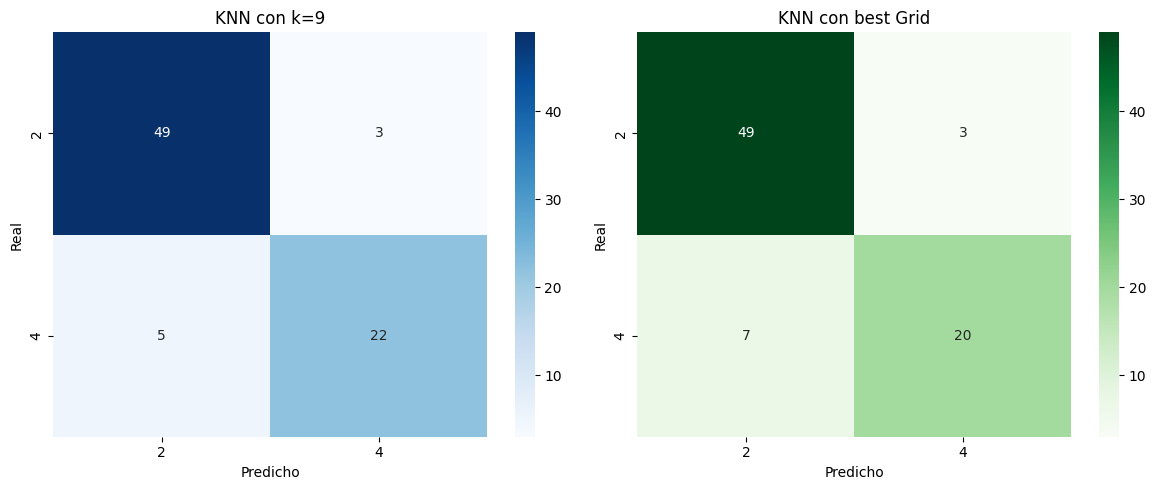

In [260]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
# Matrices
cm_grid  = confusion_matrix(y_test, y_pred_grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_knn9, annot=True, fmt='d', cmap='Blues',
            xticklabels=[2,4], yticklabels=[2,4], ax=axes[0])
axes[0].set_title("KNN con k=9")
axes[0].set_xlabel("Predicho")
axes[0].set_ylabel("Real")

sns.heatmap(cm_grid, annot=True, fmt='d', cmap='Greens',
            xticklabels=[2,4], yticklabels=[2,4], ax=axes[1])
axes[1].set_title("KNN con best Grid")
axes[1].set_xlabel("Predicho")
axes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()

El valor de k obtenido mediante GridSearchCV fue distinto al seleccionado previamente mediante validación cruzada manual. Esto se debe a que el proceso de GridSearch no solo evaluó diferentes valores de k, sino también otros hiperparámetros del modelo, particularmente la métrica de distancia, seleccionando finalmente la distancia Manhattan en lugar de la distancia Euclidiana, que es la utilizada por defecto en KNN. 

Los resultados indican que el modelo KNN con k=9 y distancia euclidiana obtuvo mejores métricas de desempeño que el modelo con k=15 y distancia Manhattan. Esto puede explicarse porque valores más altos de k tienden a suavizar en exceso las predicciones al considerar un mayor número de vecinos, lo que puede generar subajuste, ya que la predicción se basa en un promedio de más observaciones y se pierden patrones locales en los datos. En cambio, un valor intermedio de k, como 9, permite capturar mejor las relaciones locales entre las observaciones. Además, la distancia euclidiana suele funcionar mejor cuando las variables han sido previamente normalizadas, ya que mide la distancia directa entre puntos en el espacio de variables. Por otro lado, la distancia Manhattan se basa en la suma de diferencias absolutas entre dimensiones, lo que en algunos casos puede ser menos sensible a la estructura real de los datos y afectar el desempeño del modelo.

No obstante, ambos enfoques no se contradicen, ya que los resultados obtenidos presentan desempeños muy similares en términos de accuracy, lo que indica que el modelo es relativamente estable frente a pequeñas variaciones en sus hiperparámetros.

<b><font color= "red">Lección 8: Algoritmos de Boosting</b></font>                 
<b>Implementar un modelo avanzado usando Gradient Boosting</b>

**Entrenar un modelo con GradientBoostingRegressor**

In [261]:
x = df_model.drop("Yearly Amount Spent", axis=1)
y = df_model["Yearly Amount Spent"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

Para optimizar el modelo GradientBoostingRegressor se realizó una búsqueda de hiperparámetros mediante GridSearchCV, enfocándose en tres parámetros clave: n_estimators, learning_rate y max_depth. Estos hiperparámetros se seleccionaron porque tienen un impacto directo en el proceso de aprendizaje del algoritmo. El parámetro n_estimators controla la cantidad de árboles que se construyen en el modelo, learning_rate determina cuánto contribuye cada árbol a la corrección del error del modelo anterior y max_depth regula la complejidad de los árboles individuales.

Aunque existen otros hiperparámetros que también podrían optimizarse en Gradient Boosting, como subsample, min_samples_split o min_samples_leaf, en este caso decidió centrarse en estos tres debido a que suelen ser los que más influyen en el desempeño del modelo, permitiendo mejorar la capacidad predictiva sin aumentar excesivamente la complejidad del proceso de búsqueda (<u>ya que se advierte que el proceso es más demoroso computacionalmente </u>)

In [262]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

param_grid = {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.01, 0.03, 0.1],
    "max_depth": [2, 3, 4]
}

gb = GradientBoostingRegressor(random_state=42)

grid = GridSearchCV(
    gb,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

grid.fit(x_train, y_train)

print(grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 500}


In [263]:
from sklearn.ensemble import GradientBoostingRegressor

# Modelo Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=2,
    random_state=42
)

# Entrenamiento
gb_model.fit(x_train, y_train)

# Predicciones
y_pred_gb = gb_model.predict(x_test)

# Métricas
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)

print("Gradient Boosting")
print("MAE:", mae_gb)
print("MSE:", mse_gb)
print("RMSE:", rmse_gb)

Gradient Boosting
MAE: 11.735354405275066
MSE: 200.57936778551348
RMSE: 14.162604555148516


**Comparar desempeño frente al modelo lineal optimizado.**

In [264]:
import pandas as pd

resultados = pd.DataFrame({
    "Modelo": ["Regresión Lineal Optimizada", "Gradient Boosting"],
    "MAE": [mae_lasso, mae_gb],
    "MSE": [mse_lasso, mse_gb],
    "RMSE": [rmse_lasso, rmse_gb]
})

resultados.round(4)

,Modelo,MAE,MSE,RMSE
0,Regresión Lineal Optimizada,8.5761,110.6428,10.5187
1,Gradient Boosting,11.7354,200.5794,14.1626


Se comparó el desempeño del modelo de Regresión Lasso optimizado con el modelo de Gradient Boosting Regressor utilizando las métricas MAE, MSE y RMSE. Los resultados muestran que la regresión Lasso obtuvo errores significativamente menores en todas las métricas evaluadas (MAE = 8.5761, MSE = 110.6428 y RMSE = 10.5187) en comparación con Gradient Boosting (MAE = 11.7354, MSE = 200.5794 y RMSE = 14.1626).

Esto sugiere que, para este conjunto de datos, un modelo lineal regularizado logra capturar adecuadamente la relación entre las variables predictoras y la variable objetivo. Aunque los métodos de boosting suelen ser más potentes para modelar relaciones no lineales complejas, en este caso su mayor flexibilidad no se tradujo en una mejora del desempeño predictivo.

No obstante, este resultado no significa que Gradient Boosting sea un modelo inferior. Es probable que el conjunto de datos presente relaciones mayormente lineales entre las variables, lo que permite que el modelo Lasso capture de forma eficiente la estructura de los datos. Además, el modelo de Gradient Boosting utilizado no fue sometido a un proceso exhaustivo de ajuste de hiperparámetros (tuning), por lo que su desempeño podría mejorar al optimizar parámetros como subsample (proporción de datos utilizada para entrenar cada árbol), min_samples_split (número mínimo de muestras necesarias para dividir un nodo) y min_samples_leaf (número mínimo de observaciones requeridas en una hoja del árbol). Estos parámetros ayudan a controlar la complejidad del modelo y a prevenir el sobreajuste. Pero es un proceso que demora más computacionalmente.

**Explicar ventajas y limitaciones del enfoque ensemble.**

<u>Ventajas del enfoque Ensemble</u>

Los métodos ensemble combinan múltiples modelos para generar una predicción final más robusta. Al integrar varios modelos, suelen lograr mayor precisión predictiva que un solo modelo. También permiten capturar relaciones complejas o no lineales entre las variables. Además, ayudan a reducir el sesgo y la varianza, mejorando la capacidad de generalización. Por estas razones, son ampliamente utilizados en problemas de aprendizaje automático.

<u>Limitaciones del enfoque Ensemble</u>

Una de las principales limitaciones es su mayor costo computacional, ya que deben entrenarse múltiples modelos. También presentan menor interpretabilidad, lo que dificulta entender cómo cada variable influye en la predicción. Además, suelen requerir ajuste de hiperparámetros para alcanzar un buen desempeño. Este proceso puede implicar mayor tiempo de experimentación. Por ello, su uso debe evaluarse según las necesidades del problema.

<b><font color= "red">CONCLUSIÓN</b></font>     

A lo largo de este proyecto se aplicó un flujo completo de trabajo de ciencia de datos, que incluyó la exploración y preprocesamiento de los datos, la selección de variables, la construcción de distintos modelos predictivos y la evaluación de su desempeño mediante métricas adecuadas. Este proceso permitió identificar qué variables influyen en mayor medida en el gasto anual de los clientes, así como comparar distintos enfoques de modelamiento, desde modelos lineales regularizados como Ridge y Lasso, hasta algoritmos más complejos como KNN y Gradient Boosting. Los resultados mostraron que modelos relativamente simples, correctamente optimizados, pueden lograr un alto nivel de precisión, lo que resalta la importancia de comprender la estructura de los datos antes de aplicar modelos más complejos.

Desde la perspectiva de un Data Scientist, este tipo de análisis permite transformar datos de comportamiento de clientes en información accionable para la empresa. En el contexto de un negocio de e-commerce, modelos predictivos como los desarrollados en este proyecto pueden ayudar a estimar el gasto futuro de los clientes, identificar perfiles de alto valor y apoyar decisiones estratégicas de marketing y fidelización. De esta forma, la ciencia de datos se convierte en una herramienta clave para optimizar recursos, mejorar la experiencia del cliente y aumentar la rentabilidad del negocio mediante decisiones basadas en evidencia.